# 📱 Mobile Price Classification
## Logistic Regression — Binary Classification (Basic vs Premium)
- **Class 0** → Basic Price
- **Class 1** → Premium Price


## Step 1: Import Libraries

In [2]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!



## Step 2: Load the Data

In [3]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
train_df.head()

Train shape: (2000, 21)
Test shape : (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



## Step 3: Data Cleaning & Exploration

In [4]:
# Check for missing values
print('=== Missing Values ===')
print(train_df.isnull().sum())
print('\nTotal missing:', train_df.isnull().sum().sum())

=== Missing Values ===
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total missing: 0


In [20]:
# Check data types
print('=== Data Types ===')
print(train_df.dtypes)
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv("test.csv")
test_data.info()
train_data.info()

=== Data Types ===
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non

In [6]:
# Check for duplicates
print('Duplicate rows:', train_df.duplicated().sum())
train_df = train_df.drop_duplicates()
print('After removing duplicates:', train_df.shape)

Duplicate rows: 0
After removing duplicates: (2000, 21)


In [7]:
# Basic statistics
train_df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


=== Price Range Distribution (All Classes) ===
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


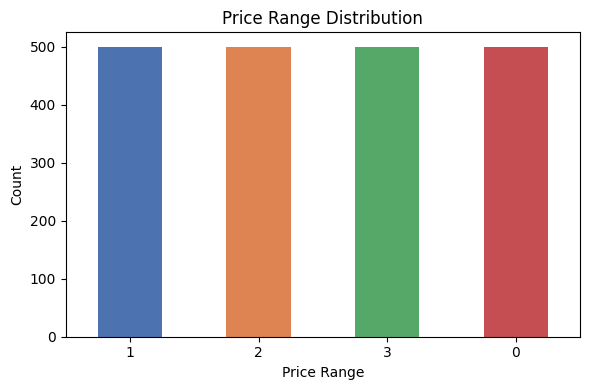

In [8]:
# Check original class distribution
print('=== Price Range Distribution (All Classes) ===')
print(train_df['price_range'].value_counts())

plt.figure(figsize=(6,4))
train_df['price_range'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 4: Filter for Binary Classification (Class 0 and Class 1 Only)

Binary dataset shape: (1000, 21)

Class distribution:
price_range
1    500
0    500
Name: count, dtype: int64


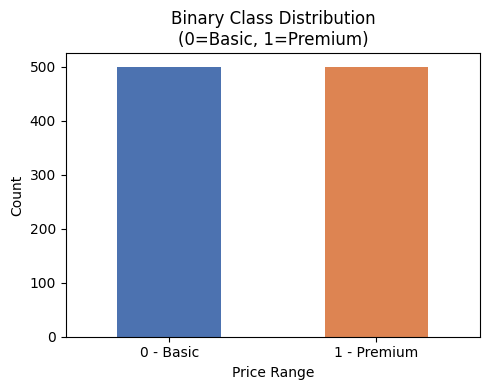

In [9]:
# Keep only class 0 (Basic) and class 1 (Premium)
binary_df = train_df[train_df['price_range'].isin([0, 1])].copy()

print('Binary dataset shape:', binary_df.shape)
print('\nClass distribution:')
print(binary_df['price_range'].value_counts())

plt.figure(figsize=(5,4))
binary_df['price_range'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Binary Class Distribution\n(0=Basic, 1=Premium)')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.xticks([0,1], ['0 - Basic', '1 - Premium'], rotation=0)
plt.tight_layout()
plt.show()


## Step 5: Define Features (X) and Target (y)

In [10]:
# Features = all columns except the target
X = binary_df.drop('price_range', axis=1)
y = binary_df['price_range']

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('\nFeature columns:', list(X.columns))

Features shape: (1000, 20)
Target shape  : (1000,)

Feature columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']



## Step 6: Train / Validation Split

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% validation
    random_state=42,
    stratify=y           # keep class balance
)

print('Training set  :', X_train.shape)
print('Validation set:', X_val.shape)

Training set  : (800, 20)
Validation set: (200, 20)



## Step 7: Feature Scaling
> ⚠️ Logistic Regression requires scaled features for best performance

In [13]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print('✅ Scaling complete!')

✅ Scaling complete!



## Step 8: Train the Logistic Regression Model

In [14]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print('✅ Model trained successfully!')

✅ Model trained successfully!



## Step 9: Evaluate the Model

In [15]:
# Predictions
y_pred = model.predict(X_val_scaled)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f'✅ Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

✅ Validation Accuracy: 0.9800 (98.00%)


In [16]:
# Detailed classification report
print('=== Classification Report ===')
print(classification_report(y_val, y_pred, target_names=['Basic (0)', 'Premium (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

   Basic (0)       0.99      0.97      0.98       100
 Premium (1)       0.97      0.99      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



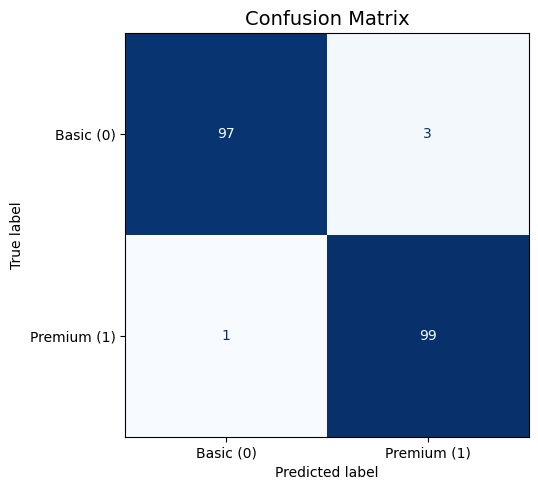

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Basic (0)', 'Premium (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()


## Step 10: Feature Importance (Coefficients)

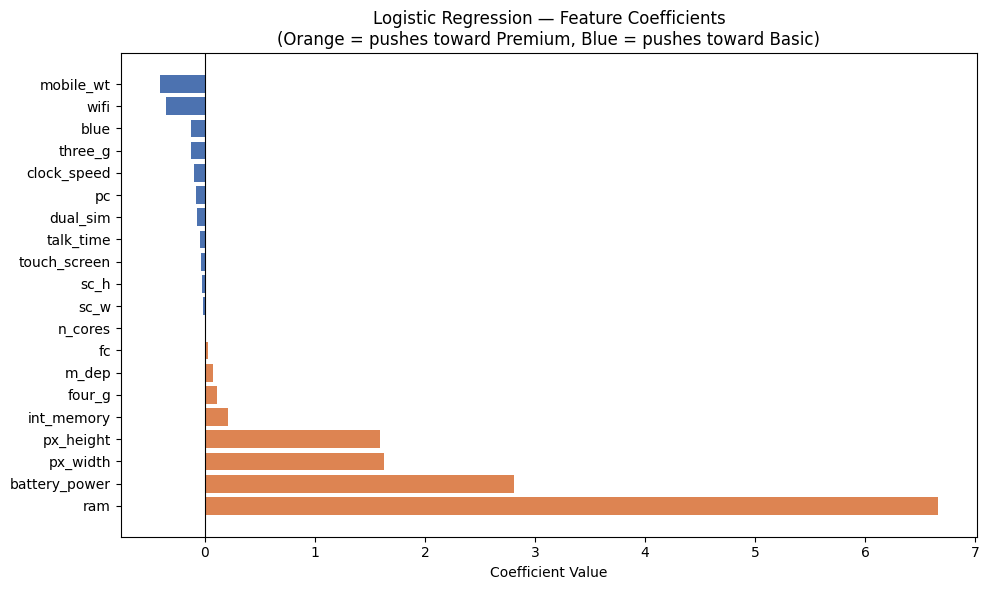

      Feature  Coefficient
          ram     6.662085
battery_power     2.809449
     px_width     1.624307
    px_height     1.591137
   int_memory     0.209269
       four_g     0.112319
        m_dep     0.078722
           fc     0.026899
      n_cores     0.002815
         sc_w    -0.012005
         sc_h    -0.027040
 touch_screen    -0.034311
    talk_time    -0.045939
     dual_sim    -0.073428
           pc    -0.084459
  clock_speed    -0.101865
      three_g    -0.123409
         blue    -0.125102
         wifi    -0.348835
    mobile_wt    -0.410236


In [18]:
# Show which features matter most
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients\n(Orange = pushes toward Premium, Blue = pushes toward Basic)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

---
## ✅ Summary

| Step | Action |
|------|--------|
| 1 | Loaded train & test datasets |
| 2 | Cleaned data (nulls, duplicates, dtypes) |
| 3 | Filtered for binary classes 0 and 1 |
| 4 | Split into train/validation (80/20) |
| 5 | Scaled features with StandardScaler |
| 6 | Trained Logistic Regression model |
| 7 | Evaluated with accuracy, report & confusion matrix |